In [1]:
## import stuff
from datetime import date
from matplotlib import pyplot as plt
import numpy as np
import os
import tifffile as tiff
import glob as glob
from pathlib import Path

# we need to set the current path to the directory
# containing the suite3d repository, this hack should
# do the trick
os.chdir(os.path.dirname(os.path.abspath("")))

from suite3d.job import Job
from suite3d import io
from suite3d import plot_utils as plot

In [2]:
# define path to data
#path = Path("/mnt/imaging1/imaging1/Veronique/2p_datasets/OFL/477116/20251118") # this is actually path to multiday data not 3d data
path = Path("/home/user/Desktop/Veronique/test_francesco/")

# Check if it exists
if path.exists():
    print("Path exists!")
else:
    print("Path does not exist.")

# get tif files
tifs = io.get_tif_paths(path)
for tif in tifs: print(tif)




Path exists!
/home/user/Desktop/Veronique/test_francesco/477116_20251118_00001_0_6000.tif


In [3]:
print(io.get_vol_rate(tifs[0]))

29.96393939393939


In [4]:
# Set the mandatory parameters
# for now some parameters are just guesses
params = {
    # volume rate
    'fs': io.get_vol_rate(tifs[0]),
    
    # planes to analyze (we have 3 planes)
    'planes' : np.array([0,1,2]), 
    # number of planes recorded 
    'n_ch_tif' : 3,
    
    # Decay time of the Ca indicator in seconds. 1.3 for GCaMP6s. This example is for GCamP8m
    'tau' : 1.3,
    'lbm' : False, 
    'num_colors' : 1, # how many color channels were recorded by scanimage
    'functional_color_channel' : 0, # which color channel is the functional one
     # voxel size in z,y,x in microns
    'voxel_size_um' : (30, 0.84, 0.84),
    # number of files to use for the initial pass
    # usually, ~500 frames is a good rule of thumb
    # we will just use 200 here for speed
    'n_init_files' :  1,  # more of those makes it crash due to mem issues
    "init_n_frames": 500,

    # 3D GPU registration - fast! 
    '3d_reg' : True,
    'gpu_reg' : True,
    
    # note : 3D CPU is not supported yet
    'subtract_crosstalk' : False, # turn off some lbm-only features
    'fuse_strips' : False, # turn off some lbm-only features
    "cell_filt_xy_um": 8,

    
    "split_tif_size": 100, 
    "peak_thresh": 0.5,
    "extend_thresh": 0.005,
    #"activity_thresh": 8.0,
    #"percentile": 90.0,
    #"extend_thresh": 0.1,
    #"max_pix": 1000,

    
    
    
}



In [5]:
### Create the job
job = Job(r'/home/user/Desktop/Veronique/test_francesco/','xy_1000', tifs = tifs,
          params=params, create=True, overwrite=True, verbosity = 3)
job.params.update(params)        


Loading job directory for xy_1000 in /home/user/Desktop/Veronique/test_francesco/
      Created dir /home/user/Desktop/Veronique/test_francesco/s3d-xy_1000/registered_fused_data
      Created dir /home/user/Desktop/Veronique/test_francesco/s3d-xy_1000/summary
      Created dir /home/user/Desktop/Veronique/test_francesco/s3d-xy_1000/iters
   Loading default params
      Updating param fs
      Updating param planes
      Updating param n_ch_tif
      Updating param tau
      Updating param lbm
      Updating param num_colors
      Updating param functional_color_channel
      Updating param voxel_size_um
      Updating param n_init_files
      Updating param init_n_frames
      Updating param 3d_reg
      Updating param gpu_reg
      Updating param subtract_crosstalk
      Updating param fuse_strips
      Updating param cell_filt_xy_um
      Updating param split_tif_size
      Updating param peak_thresh
      Updating param extend_thresh
   Updated main params file


In [6]:
job.run_init_pass()

   Saved a copy of params at /home/user/Desktop/Veronique/test_francesco/s3d-xy_1000/summary
   Updated main params file
Launching initial pass
Saving summary to /home/user/Desktop/Veronique/test_francesco/s3d-xy_1000/summary/summary.npy
   Loading init tifs with 3 channels
      Loading tiff 1/1: /home/user/Desktop/Veronique/test_francesco/477116_20251118_00001_0_6000.tif
   Loaded 1 files, total 2.93 GB
   Selecting 500 random frames from the init tif files
   Loaded movie with 500 frames and shape 3, 512, 512
      Enforcing positivity in mean image
   No crosstalk estimation or subtraction
   Using 3d registration
   Computing plane alignment shifts
   Applying plane alignment shifts
   Launching 3D GPU reference image calculation
      Seeding reference image with most active frames
      Completed iter 1 out of 8 in  1.98s using  69/500 frames
      Completed iter 2 out of 8 in  2.00s using  123/500 frames
      Completed iter 3 out of 8 in  2.04s using  177/500 frames
      Comp

In [7]:
# If you have large tiffs, split the large tiffs into files of size 100 after registration
job.params['split_tif_size'] = 100

(<Figure size 450x600 with 1 Axes>,
 <Axes: >,
 <matplotlib.image.AxesImage at 0x7f709f717390>)

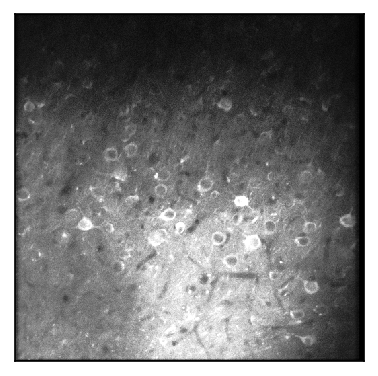

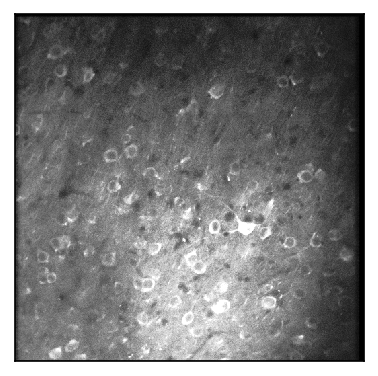

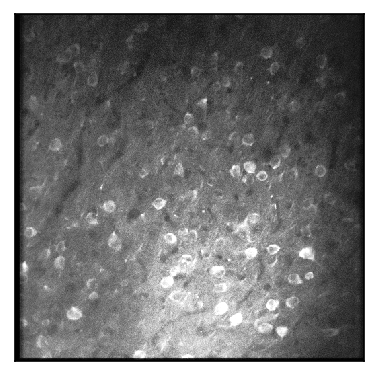

In [8]:
# OPTIONAL: load and take a look at the reference image
summary = job.load_summary()
ref_img = summary['ref_img_3d']

# # view 1 plane at a time
plot.show_img(ref_img[0], figsize=(3,4))
plot.show_img(ref_img[1], figsize=(3,4))
plot.show_img(ref_img[2], figsize=(3,4))

# # interactive 3D viewer
# plot.VolumeViewer(ref_img)

In [9]:
job.register()

      Found dir /home/user/Desktop/Veronique/test_francesco/s3d-xy_1000/registered_fused_data
      Updating self.dirs tag registered_fused_data
   Saved a copy of params at /home/user/Desktop/Veronique/test_francesco/s3d-xy_1000/registered_fused_data
   Updated main params file
   Starting registration: 3D: True, GPU: True
   Not clipping frames for registration
Will analyze 1 tifs in 1 batches
   Enforcing positivity
   Launching IO thread
         Memory at batch 0.  Total Used: 007.243 GB, Virtual Available: 055.611 GB, Virtual Used: 007.045 GB, Swap Used: 000.198 GB
Loading Batch 0 of 0
      Loading tiff 1/1: /home/user/Desktop/Veronique/test_francesco/477116_20251118_00001_0_6000.tif
   Loaded 1 files, total 2.93 GB
   Batch 0 IO thread joined
         Memory after IO thread joinTotal Used: 010.184 GB, Virtual Available: 052.670 GB, Virtual Used: 009.985 GB, Swap Used: 000.198 GB
         Memory after movie copied from threadTotal Used: 013.120 GB, Virtual Available: 049.733 GB,

In [10]:
corr_map = job.calculate_corr_map()

   Created dir /home/user/Desktop/Veronique/test_francesco/s3d-xy_1000/corrmap with tag corrmap
      Updating self.dirs tag corrmap
   Created dir /home/user/Desktop/Veronique/test_francesco/s3d-xy_1000/mov_sub with tag mov_sub
      Updating self.dirs tag mov_sub
   Updated detection_timebin to 23 based on framerate and tau
   Saved a copy of params at /home/user/Desktop/Veronique/test_francesco/s3d-xy_1000/corrmap
   Updated main params file
   Computing correlation map of movie with 2000 frames, volume shape: 3, 516, 519
      Running batch 1 of 3
      Binning with timebin of size 23
         Timer batch_timebin completed in 0.003 sec
         Timer prep completed in 0.627 sec
         Timer batch_setup completed in 0.021 sec
         Timer batch_edgecrop completed in 0.003 sec
         Timer accum_meanmeax completed in 0.030 sec
         Timer batch_rolling_mean_filt completed in 0.023 sec
         Timer batch_accum_sdmov completed in 0.061 sec
         Timer batch_norm_sdmov com

/home/user/miniforge3/envs/suite3d/lib/python3.11/multiprocessing/resource_tracker.py:254: UserWarning: resource_tracker: There appear to be 2 leaked shared_memory objects to clean up at shutdown
  warnings.warn('resource_tracker: There appear to be %d '
/home/user/miniforge3/envs/suite3d/lib/python3.11/multiprocessing/resource_tracker.py:267: UserWarning: resource_tracker: '/psm_1ca468e1': [Errno 2] No such file or directory: '/psm_1ca468e1'
  warnings.warn('resource_tracker: %r: %s' % (name, e))
/home/user/miniforge3/envs/suite3d/lib/python3.11/multiprocessing/resource_tracker.py:267: UserWarning: resource_tracker: '/psm_bed3a807': [Errno 2] No such file or directory: '/psm_bed3a807'
  warnings.warn('resource_tracker: %r: %s' % (name, e))
/home/user/miniforge3/envs/suite3d/lib/python3.11/multiprocessing/resource_tracker.py:254: UserWarning: resource_tracker: There appear to be 2 leaked shared_memory objects to clean up at shutdown
  warnings.warn('resource_tracker: There appear to be

         Timer batch_setup completed in 0.021 sec
         Timer batch_edgecrop completed in 0.003 sec
         Timer accum_meanmeax completed in 0.037 sec
         Timer batch_rolling_mean_filt completed in 0.022 sec
         Timer batch_accum_sdmov completed in 0.061 sec
         Timer batch_norm_sdmov completed in 0.017 sec
         Loading movie of size (34, 3, 516, 519) into shared memory
         Timer dtu_shmem completed in 0.117 sec
         Subtracting neuropil and applying cell filters
         Timer dtu_npsub_conv3d completed in 1.272 sec
         Reducing filtered movie to compute correlation map
         Timer dtu_vmap completed in 0.032 sec
         Timer dtu_cleanup completed in 0.066 sec
         Timer batch_filt_reduce completed in 1.489 sec
         Timer batch_accum_vmap completed in 0.004 sec
         Timer batch completed in 2.064 sec
         Timer save completed in 0.144 sec
      Running batch 3 of 3
      Binning with timebin of size 23
         Timer batch_tim

In [11]:
res = job.load_corr_map_results()
vmap = res['vmap']

(<Figure size 450x600 with 1 Axes>,
 <Axes: >,
 <matplotlib.image.AxesImage at 0x7f709ff94cd0>)

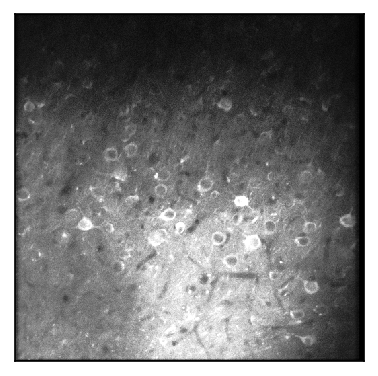

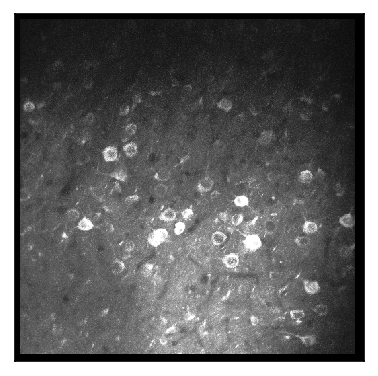

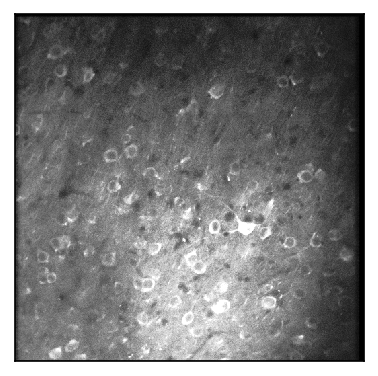

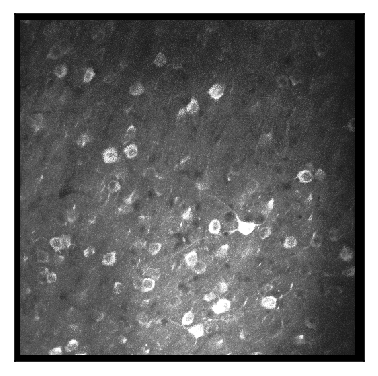

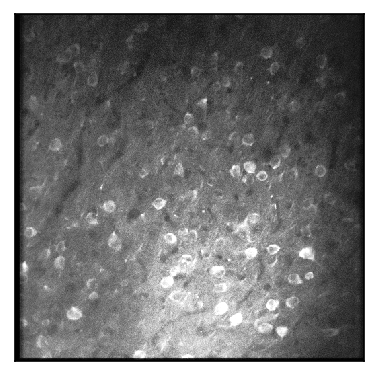

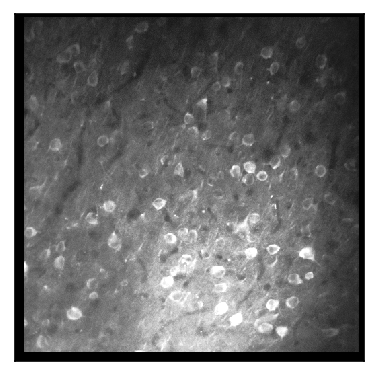

In [12]:
plot.show_img(ref_img[0], figsize=(3,4))
plot.show_img(res['max_img'][0], figsize=(3,4))

plot.show_img(ref_img[1], figsize=(3,4))
plot.show_img(res['max_img'][1], figsize=(3,4))

plot.show_img(ref_img[2], figsize=(3,4))
plot.show_img(res['mean_img'][2], figsize=(3,4))

In [ ]:
job.params['patch_size_xy'] = (1000, 1000)
# for speed, only segment a single patch
job.segment_rois()



   Created dir /home/user/Desktop/Veronique/test_francesco/s3d-xy_1000/segmentation with tag segmentation
      Updating self.dirs tag segmentation
   Saved a copy of params at /home/user/Desktop/Veronique/test_francesco/s3d-xy_1000/segmentation
   Updated main params file
   Created dir /home/user/Desktop/Veronique/test_francesco/s3d-xy_1000/rois with tag rois
      Updating self.dirs tag rois
   Saving results to /home/user/Desktop/Veronique/test_francesco/s3d-xy_1000/segmentation and /home/user/Desktop/Veronique/test_francesco/s3d-xy_1000/rois 
dict_keys(['max_img', 'mean_img', 'vmap', 'vmap_raw', 'all_params'])
   Detecting from patch 1 / 1
   Created dir /home/user/Desktop/Veronique/test_francesco/s3d-xy_1000/segmentation/patch-0000 with tag segmentation-patch-0000
         Loading 0.13 GB movie to memory, shape: (85, 3, 516, 519) 
         Loaded
         Loading movie patch to shared memory
         Loaded
      Starting extraction with peak_thresh: 0.500 and Th2: 5.000
        

In [ ]:
job.compute_npil_masks()
traces = job.extract_and_deconvolve()

In [ ]:
job.export_results('/home/user/Desktop/Veronique/test_francesco/s3d-xy_1000/',result_dir_name='rois')